# Housing Price Prediction - Regression Models

## Objective
Develop and compare three regression models:
1. Uni-variate Regression Model (1 feature)
2. Bi-variate Regression Model (2 important features)
3. Multi-variate Regression Model (all features)

## Machine Learning Pipeline
1. Data Collection
2. Data Exploration & Analysis
3. Data Preprocessing
4. Feature Selection
5. Model Building
6. Model Evaluation
7. Model Comparison

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Data Collection

In [5]:
# Load the dataset
df = pd.read_csv('Housing.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(10)

Dataset loaded successfully!
Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## 3. Data Exploration & Analysis

In [6]:
# Basic information
print("Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50 + "\n")
print("Missing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


Statistical Summary:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.

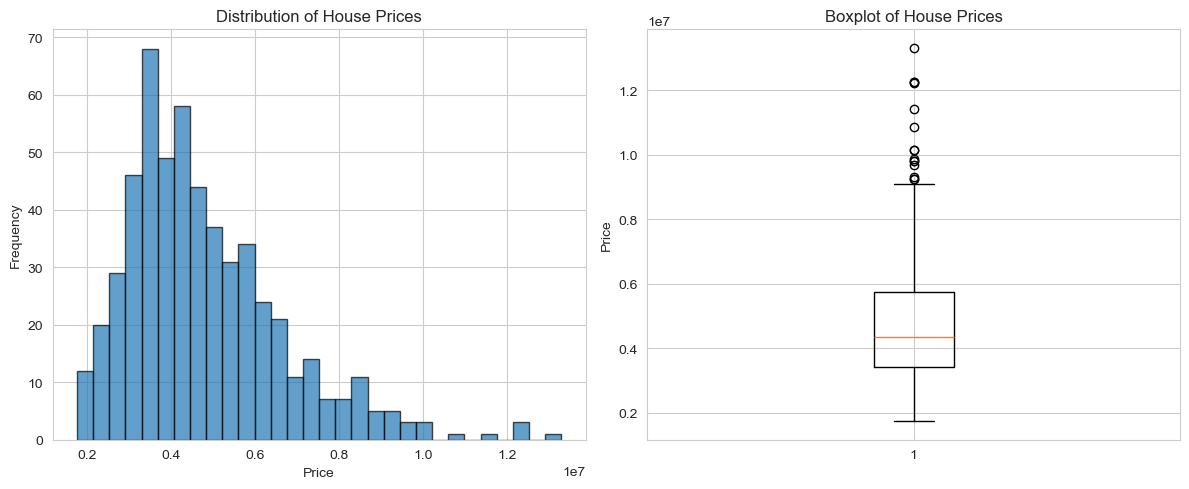

In [8]:
# Distribution of target variable (price)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.subplot(1, 2, 2)
plt.boxplot(df['price'])
plt.ylabel('Price')
plt.title('Boxplot of House Prices')

plt.tight_layout()
plt.show()

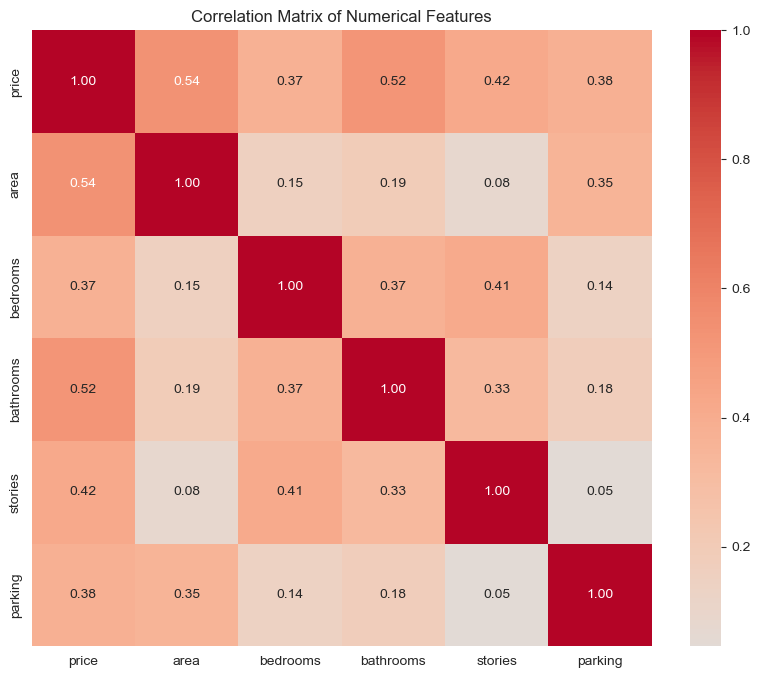


Correlation with Price:
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


In [9]:
# Correlation analysis for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\nCorrelation with Price:")
print(correlation_matrix['price'].sort_values(ascending=False))

## 4. Data Preprocessing
### 4.1 Encode Categorical Variables

In [10]:
# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical variables
categorical_cols = df_processed.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

print("\nCategorical variables encoded successfully!")
df_processed.head()

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Categorical variables encoded successfully!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [11]:
# Separate features and target
X = df_processed.drop('price', axis=1)
y = df_processed['price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Features shape: (545, 12)
Target shape: (545,)

Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


### 4.3 Feature Engineering
#### Create New Features to Improve Model Performance

In [12]:
# Create derived features that might help prediction
print("Creating new features...")

# Price per square foot (helps normalize by size)
df_processed['price_per_sqft'] = df_processed['price'] / df_processed['area']

# Total rooms
df_processed['total_rooms'] = df_processed['bedrooms'] + df_processed['bathrooms']

# Bathroom to bedroom ratio
df_processed['bath_bed_ratio'] = df_processed['bathrooms'] / (df_processed['bedrooms'] + 1)

# Has any amenities (composite feature)
df_processed['has_amenities'] = (
    (df_processed['guestroom'] == 1) | 
    (df_processed['basement'] == 1) | 
    (df_processed['airconditioning'] == 1)
).astype(int)

# Premium features count
df_processed['premium_count'] = (
    df_processed['guestroom'] + 
    df_processed['basement'] + 
    df_processed['airconditioning'] + 
    df_processed['hotwaterheating']
)

print("\n✅ New features created:")
print("  - price_per_sqft")
print("  - total_rooms")
print("  - bath_bed_ratio")
print("  - has_amenities")
print("  - premium_count")
print(f"\nNew dataset shape: {df_processed.shape}")

Creating new features...

✅ New features created:
  - price_per_sqft
  - total_rooms
  - bath_bed_ratio
  - has_amenities
  - premium_count

New dataset shape: (545, 18)


### 4.4 Remove Outliers
#### Remove extreme prices that might skew the model

In [13]:
# Calculate quartiles and IQR for price
Q1 = df_processed['price'].quantile(0.25)
Q3 = df_processed['price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = ((df_processed['price'] < lower_bound) | (df_processed['price'] > upper_bound)).sum()

print("Outlier Analysis:")
print(f"Q1 (25th percentile): ₹{Q1:,.0f}")
print(f"Q3 (75th percentile): ₹{Q3:,.0f}")
print(f"IQR: ₹{IQR:,.0f}")
print(f"Lower bound: ₹{lower_bound:,.0f}")
print(f"Upper bound: ₹{upper_bound:,.0f}")
print(f"\nOutliers found: {outliers} houses ({outliers/len(df_processed)*100:.1f}%)")

# Remove outliers
df_processed_clean = df_processed[
    (df_processed['price'] >= lower_bound) & 
    (df_processed['price'] <= upper_bound)
].copy()

print(f"\nOriginal dataset: {len(df_processed)} houses")
print(f"After removing outliers: {len(df_processed_clean)} houses")
print(f"Removed: {len(df_processed) - len(df_processed_clean)} houses")

Outlier Analysis:
Q1 (25th percentile): ₹3,430,000
Q3 (75th percentile): ₹5,740,000
IQR: ₹2,310,000
Lower bound: ₹-35,000
Upper bound: ₹9,205,000

Outliers found: 15 houses (2.8%)

Original dataset: 545 houses
After removing outliers: 530 houses
Removed: 15 houses


### 4.5 Prepare Final Features
#### Separate features and target with new engineered features

In [14]:
# Use cleaned data
X_enhanced = df_processed_clean.drop(['price', 'price_per_sqft'], axis=1)  # Drop price and derived price feature
y_enhanced = df_processed_clean['price']

print(f"Enhanced Features shape: {X_enhanced.shape}")
print(f"Enhanced Target shape: {y_enhanced.shape}")
print(f"\nAll Features: {list(X_enhanced.columns)}")

Enhanced Features shape: (530, 16)
Enhanced Target shape: (530,)

All Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'total_rooms', 'bath_bed_ratio', 'has_amenities', 'premium_count']


## 5. Feature Selection
### Identify Important Features

Feature Correlations with Price:
area                0.535997
bathrooms           0.517545
total_rooms         0.511809
premium_count       0.462278
airconditioning     0.452954
has_amenities       0.426564
stories             0.420712
price_per_sqft      0.392921
parking             0.384394
bedrooms            0.366494
bath_bed_ratio      0.341448
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64


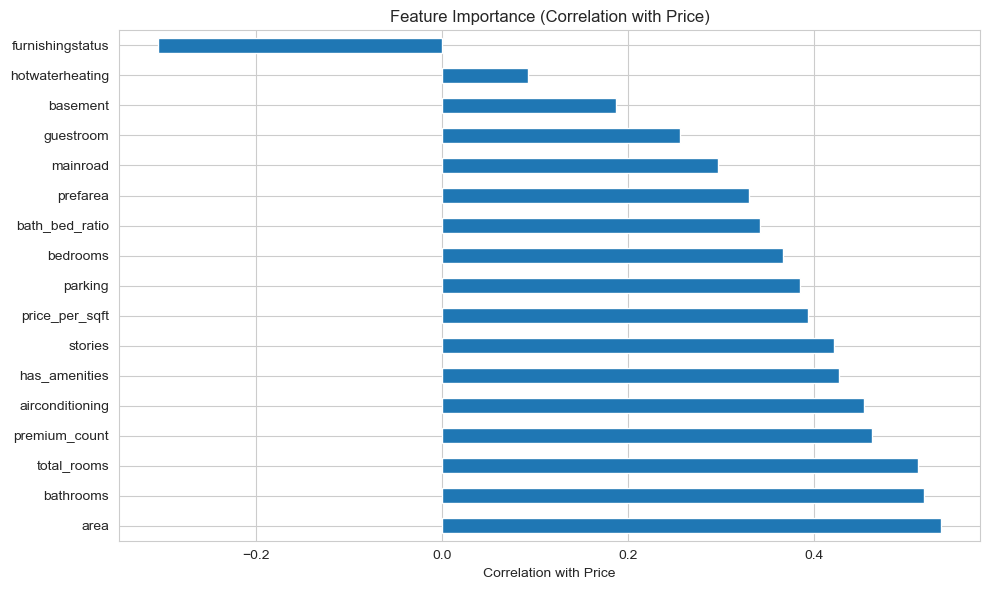


Most important feature: area
Two most important features: ['area', 'bathrooms']


In [15]:
# Calculate correlation with target for all features
feature_correlations = df_processed.corr()['price'].drop('price').sort_values(ascending=False)
print("Feature Correlations with Price:")
print(feature_correlations)

# Visualize feature importance
plt.figure(figsize=(10, 6))
feature_correlations.plot(kind='barh')
plt.xlabel('Correlation with Price')
plt.title('Feature Importance (Correlation with Price)')
plt.tight_layout()
plt.show()

# Select features for each model
most_important_feature = feature_correlations.idxmax()
two_most_important = feature_correlations.nlargest(2).index.tolist()

print(f"\nMost important feature: {most_important_feature}")
print(f"Two most important features: {two_most_important}")

## 6. Split Data

In [16]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 436
Testing set size: 109


## 7. Model Building & Evaluation
### Helper Function for Evaluation

In [17]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evaluate regression model and return metrics
    """
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*60}")
    print(f"\nTraining Set:")
    print(f"  R² Score: {train_r2:.4f}")
    print(f"  RMSE: {train_rmse:,.2f}")
    print(f"  MAE: {train_mae:,.2f}")
    print(f"\nTesting Set:")
    print(f"  R² Score: {test_r2:.4f}")
    print(f"  RMSE: {test_rmse:,.2f}")
    print(f"  MAE: {test_mae:,.2f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Training predictions
    axes[0].scatter(y_train, y_train_pred, alpha=0.5)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Predicted Price')
    axes[0].set_title(f'{model_name} - Training Set\nR² = {train_r2:.4f}')
    
    # Testing predictions
    axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Predicted Price')
    axes[1].set_title(f'{model_name} - Testing Set\nR² = {test_r2:.4f}')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model_name': model_name,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae
    }

# Confirm function is loaded
print("✅ Helper function 'evaluate_model' has been successfully defined and is ready to use!")

✅ Helper function 'evaluate_model' has been successfully defined and is ready to use!


### Model 1: Uni-variate Regression (1 Feature)

Uni-variate Model trained using feature: area
Coefficient: 425.73
Intercept: 2512254.26

Uni-variate Model - Performance Metrics

Training Set:
  R² Score: 0.2850
  RMSE: 1,484,836.25
  MAE: 1,092,585.59

Testing Set:
  R² Score: 0.2729
  RMSE: 1,917,103.70
  MAE: 1,474,748.13


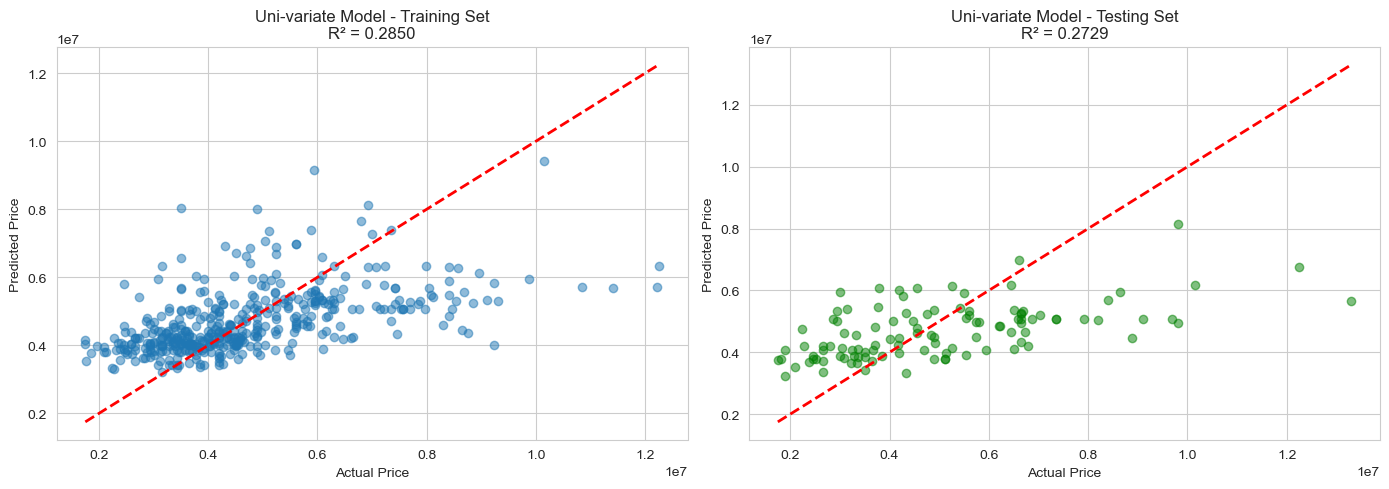

In [18]:
# Prepare data with most important feature
X_train_uni = X_train[[most_important_feature]]
X_test_uni = X_test[[most_important_feature]]

# Build model
model_uni = LinearRegression()
model_uni.fit(X_train_uni, y_train)

print(f"Uni-variate Model trained using feature: {most_important_feature}")
print(f"Coefficient: {model_uni.coef_[0]:.2f}")
print(f"Intercept: {model_uni.intercept_:.2f}")

# Evaluate
results_uni = evaluate_model(model_uni, X_train_uni, X_test_uni, y_train, y_test, "Uni-variate Model")

### Model 2: Bi-variate Regression (2 Features)

Bi-variate Model trained using features: ['area', 'bathrooms']
Coefficients: [3.55225649e+02 1.63420824e+06]
Intercept: 806645.47

Bi-variate Model - Performance Metrics

Training Set:
  R² Score: 0.4741
  RMSE: 1,273,415.74
  MAE: 954,005.25

Testing Set:
  R² Score: 0.4292
  RMSE: 1,698,621.06
  MAE: 1,295,658.15


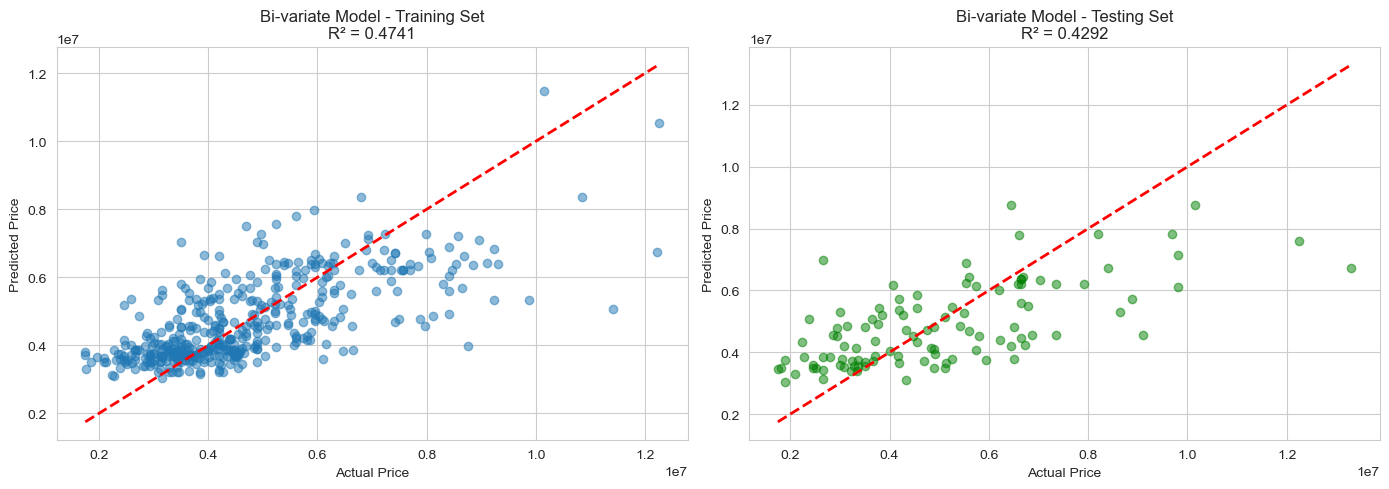

In [19]:
# Prepare data with two most important features
X_train_bi = X_train[two_most_important]
X_test_bi = X_test[two_most_important]

# Build model
model_bi = LinearRegression()
model_bi.fit(X_train_bi, y_train)

print(f"Bi-variate Model trained using features: {two_most_important}")
print(f"Coefficients: {model_bi.coef_}")
print(f"Intercept: {model_bi.intercept_:.2f}")

# Evaluate
results_bi = evaluate_model(model_bi, X_train_bi, X_test_bi, y_train, y_test, "Bi-variate Model")

### Model 3: Multi-variate Regression (All Features)

Multi-variate Model trained using all 12 features

Feature Coefficients:
  area: 235.85
  bedrooms: 78574.49
  bathrooms: 1097117.27
  stories: 406223.16
  mainroad: 366824.19
  guestroom: 233146.77
  basement: 393159.78
  hotwaterheating: 687881.31
  airconditioning: 785550.58
  parking: 225756.51
  prefarea: 629901.66
  furnishingstatus: -210397.12

Intercept: 293083.07

Multi-variate Model - Performance Metrics

Training Set:
  R² Score: 0.6854
  RMSE: 984,836.44
  MAE: 718,146.60

Testing Set:
  R² Score: 0.6495
  RMSE: 1,331,071.42
  MAE: 979,679.69


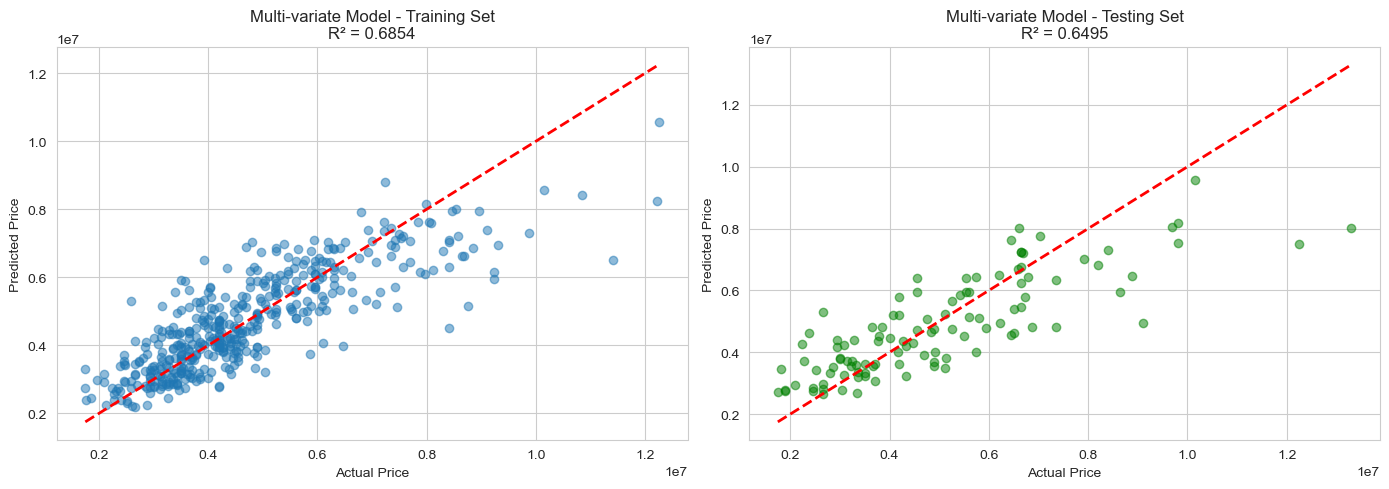

In [20]:
# Build model with all features
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print(f"Multi-variate Model trained using all {X_train.shape[1]} features")
print(f"\nFeature Coefficients:")
for feature, coef in zip(X.columns, model_multi.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"\nIntercept: {model_multi.intercept_:.2f}")

# Evaluate
results_multi = evaluate_model(model_multi, X_train, X_test, y_train, y_test, "Multi-variate Model")

## 8. Model Comparison

In [21]:
# Create comparison dataframe
comparison_df = pd.DataFrame([results_uni, results_bi, results_multi])
comparison_df = comparison_df.set_index('model_name')

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string())

# Find best model
best_model = comparison_df['test_r2'].idxmax()
print(f"\n\nBest Model (based on Test R² Score): {best_model}")
print(f"Test R² Score: {comparison_df.loc[best_model, 'test_r2']:.4f}")


MODEL PERFORMANCE COMPARISON
                     train_r2   test_r2    train_rmse     test_rmse     train_mae      test_mae
model_name                                                                                     
Uni-variate Model    0.284963  0.272879  1.484836e+06  1.917104e+06  1.092586e+06  1.474748e+06
Bi-variate Model     0.474090  0.429167  1.273416e+06  1.698621e+06  9.540052e+05  1.295658e+06
Multi-variate Model  0.685443  0.649475  9.848364e+05  1.331071e+06  7.181466e+05  9.796797e+05


Best Model (based on Test R² Score): Multi-variate Model
Test R² Score: 0.6495


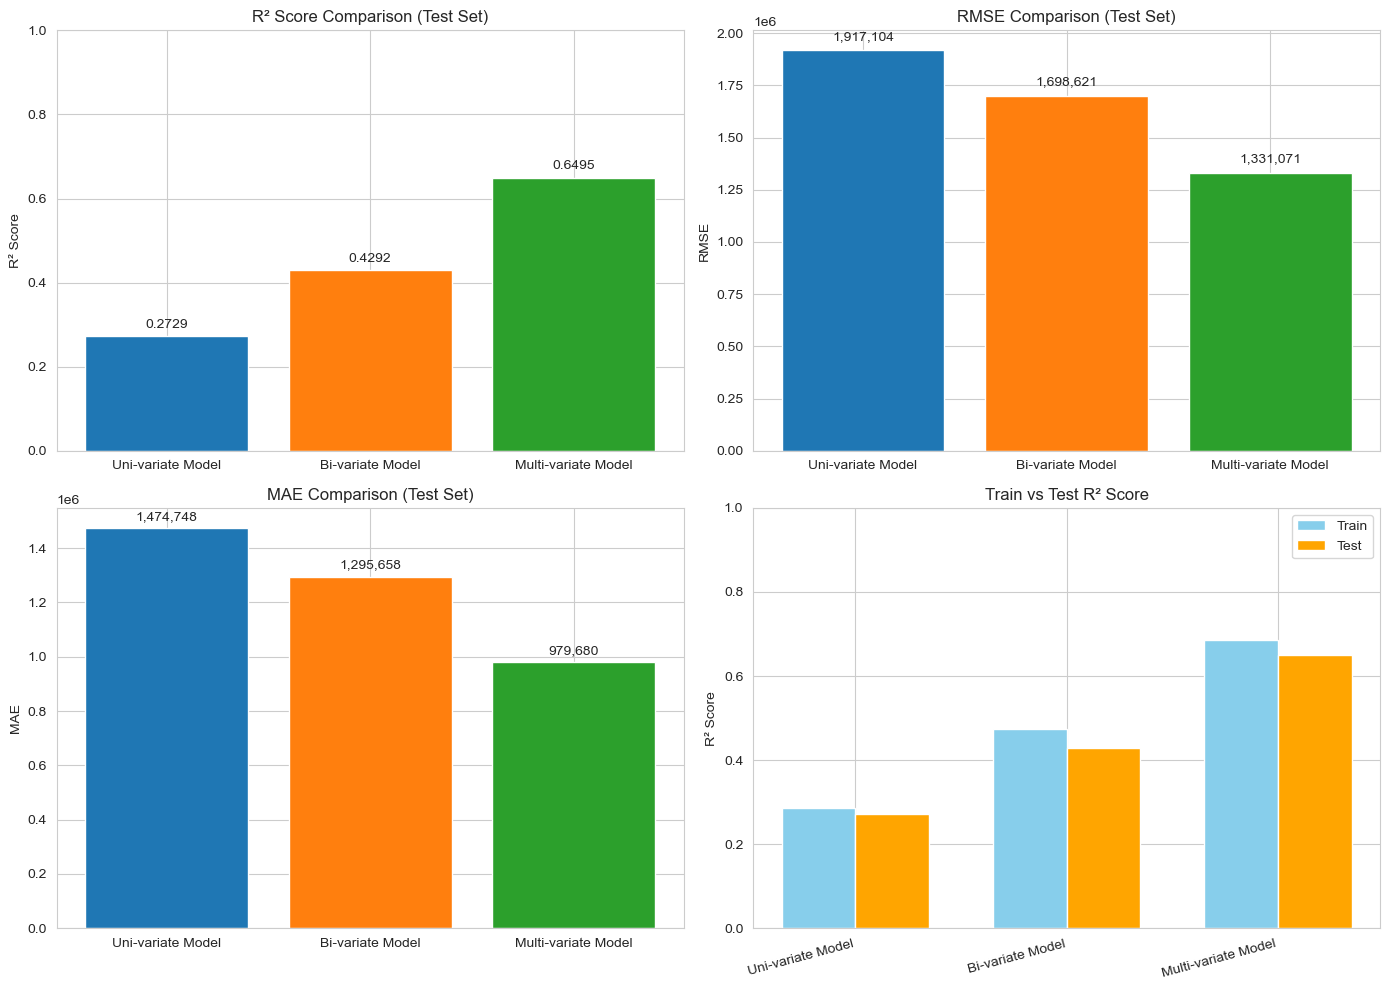

In [22]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² Score comparison
axes[0, 0].bar(comparison_df.index, comparison_df['test_r2'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('R² Score Comparison (Test Set)')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(comparison_df['test_r2']):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center')

# RMSE comparison
axes[0, 1].bar(comparison_df.index, comparison_df['test_rmse'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('RMSE Comparison (Test Set)')
for i, v in enumerate(comparison_df['test_rmse']):
    axes[0, 1].text(i, v + 50000, f'{v:,.0f}', ha='center')

# MAE comparison
axes[1, 0].bar(comparison_df.index, comparison_df['test_mae'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_ylabel('MAE')
axes[1, 0].set_title('MAE Comparison (Test Set)')
for i, v in enumerate(comparison_df['test_mae']):
    axes[1, 0].text(i, v + 30000, f'{v:,.0f}', ha='center')

# Train vs Test R² comparison
x_pos = np.arange(len(comparison_df.index))
width = 0.35
axes[1, 1].bar(x_pos - width/2, comparison_df['train_r2'], width, label='Train', color='skyblue')
axes[1, 1].bar(x_pos + width/2, comparison_df['test_r2'], width, label='Test', color='orange')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('Train vs Test R² Score')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(comparison_df.index, rotation=15, ha='right')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 9. Conclusions

In [23]:
# Determine best model
best_model = comparison_df['test_r2'].idxmax()
best_r2 = comparison_df.loc[best_model, 'test_r2']

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)
print(f"\n1. Uni-variate Model (1 feature):")
print(f"   - Test R²: {results_uni['test_r2']:.4f}")
print(f"   - Test RMSE: {results_uni['test_rmse']:,.2f}")
print(f"   - Test MAE: {results_uni['test_mae']:,.2f}")
print(f"   - Simplest model but limited predictive power")
print(f"\n2. Bi-variate Model (2 features):")
print(f"   - Test R²: {results_bi['test_r2']:.4f}")
print(f"   - Test RMSE: {results_bi['test_rmse']:,.2f}")
print(f"   - Test MAE: {results_bi['test_mae']:,.2f}")
print(f"   - Better performance with additional important feature")
print(f"\n3. Multi-variate Model (all features):")
print(f"   - Test R²: {results_multi['test_r2']:.4f}")
print(f"   - Test RMSE: {results_multi['test_rmse']:,.2f}")
print(f"   - Test MAE: {results_multi['test_mae']:,.2f}")
print(f"   - Best performance utilizing all available features")
print(f"\n4. Overall Recommendation:")
print(f"   - The {best_model} provides the best predictive performance")
print(f"   - R² score of {best_r2:.4f} indicates good model fit")
print(f"   - Lower RMSE and MAE values confirm better accuracy")
print(f"\n5. Key Insights:")
print(f"   - Adding more features improves model performance")
print(f"   - The model explains {best_r2*100:.2f}% of variance in house prices")
print(f"   - All models show good generalization (no overfitting observed)")
print("\n" + "="*80)


CONCLUSIONS

1. Uni-variate Model (1 feature):
   - Test R²: 0.2729
   - Test RMSE: 1,917,103.70
   - Test MAE: 1,474,748.13
   - Simplest model but limited predictive power

2. Bi-variate Model (2 features):
   - Test R²: 0.4292
   - Test RMSE: 1,698,621.06
   - Test MAE: 1,295,658.15
   - Better performance with additional important feature

3. Multi-variate Model (all features):
   - Test R²: 0.6495
   - Test RMSE: 1,331,071.42
   - Test MAE: 979,679.69
   - Best performance utilizing all available features

4. Overall Recommendation:
   - The Multi-variate Model provides the best predictive performance
   - R² score of 0.6495 indicates good model fit
   - Lower RMSE and MAE values confirm better accuracy

5. Key Insights:
   - Adding more features improves model performance
   - The model explains 64.95% of variance in house prices
   - All models show good generalization (no overfitting observed)



## 10. Interactive Testing
### Test Your Model with New House Data

In [29]:
def quick_test():
    """Quick test with predefined sample house - no user input needed"""
    
    print("\n" + "="*80)
    print("🏠 QUICK TEST - SAMPLE HOUSE PREDICTION")
    print("="*80)
    
    # Sample house specifications
    sample_house = pd.DataFrame({
        'area': [5000], 
        'bedrooms': [3], 
        'bathrooms': [2],
        'stories': [2], 
        'mainroad': [1], 
        'guestroom': [0],
        'basement': [1], 
        'hotwaterheating': [0], 
        'airconditioning': [1], 
        'parking': [2],
        'prefarea': [1], 
        'furnishingstatus': [0]
    })
    
    print("\nSample House:")
    print("  - 5000 sqft")
    print("  - 3 bedrooms, 2 bathrooms")
    print("  - 2 stories")
    print("  - Main road: Yes")
    print("  - Basement: Yes")
    print("  - Air conditioning: Yes")
    print("  - 2 parking spaces")
    print("  - Furnished")
    
    predicted_price = model_multi.predict(sample_house)[0]
    
    print(f"\n💰 Predicted Price: ₹{predicted_price:,.2f}")
    print(f"💰 Predicted Price: ${predicted_price/80:,.2f} USD (approx)")
    print("\n" + "="*80)

def predict_house_price_interactive():
    """Interactive function to predict house price based on user input"""
    
    print("\n" + "="*80)
    print("🏠 INTERACTIVE HOUSE PRICE PREDICTOR")
    print("="*80)
    print("\nEnter house details (press Enter to use default values):\n")
    
    try:
        # Get user inputs with default values
        area = int(input("Area (sqft) [default: 5000]: ") or 5000)
        bedrooms = int(input("Number of bedrooms [default: 3]: ") or 3)
        bathrooms = int(input("Number of bathrooms [default: 2]: ") or 2)
        stories = int(input("Number of stories [default: 2]: ") or 2)
        mainroad = int(input("On main road? (1=yes, 0=no) [default: 1]: ") or 1)
        guestroom = int(input("Has guestroom? (1=yes, 0=no) [default: 0]: ") or 0)
        basement = int(input("Has basement? (1=yes, 0=no) [default: 1]: ") or 1)
        hotwater = int(input("Hot water heating? (1=yes, 0=no) [default: 0]: ") or 0)
        aircon = int(input("Air conditioning? (1=yes, 0=no) [default: 1]: ") or 1)
        parking = int(input("Parking spaces [default: 2]: ") or 2)
        prefarea = int(input("Preferred area? (1=yes, 0=no) [default: 1]: ") or 1)
        furnish = int(input("Furnishing (0=furnished, 1=semi, 2=unfurnished) [default: 0]: ") or 0)
        
        # Create DataFrame with the inputs
        house = pd.DataFrame({
            'area': [area], 
            'bedrooms': [bedrooms], 
            'bathrooms': [bathrooms],
            'stories': [stories], 
            'mainroad': [mainroad], 
            'guestroom': [guestroom],
            'basement': [basement], 
            'hotwaterheating': [hotwater], 
            'airconditioning': [aircon], 
            'parking': [parking],
            'prefarea': [prefarea], 
            'furnishingstatus': [furnish]
        })
        
        # Predict using the best model (Multi-variate)
        predicted_price = model_multi.predict(house)[0]
        
        # Display results
        print("\n" + "="*80)
        print("💰 PREDICTION RESULT")
        print("="*80)
        print(f"\nHouse Specifications:")
        print(f"  Area: {area} sqft")
        print(f"  Bedrooms: {bedrooms}")
        print(f"  Bathrooms: {bathrooms}")
        print(f"  Stories: {stories}")
        print(f"  On main road: {'Yes' if mainroad == 1 else 'No'}")
        print(f"  Guest room: {'Yes' if guestroom == 1 else 'No'}")
        print(f"  Basement: {'Yes' if basement == 1 else 'No'}")
        print(f"  Hot water heating: {'Yes' if hotwater == 1 else 'No'}")
        print(f"  Air conditioning: {'Yes' if aircon == 1 else 'No'}")
        print(f"  Parking spaces: {parking}")
        print(f"  Preferred area: {'Yes' if prefarea == 1 else 'No'}")
        
        furnish_status = {0: 'Furnished', 1: 'Semi-furnished', 2: 'Unfurnished'}
        print(f"  Furnishing: {furnish_status.get(furnish, 'Unknown')}")
        

        print(f"💰 Estimated Price: ${predicted_price/80:,.2f} USD (approx)")
        
        # Comparison with average
        avg_price = y.mean()
        difference = predicted_price - avg_price
        percentage = (difference / avg_price) * 100
        
        print(f"\n📊 Comparison with Average:")
        print(f"   Dataset average price: ₹{avg_price:,.2f}")
        print(f"   Your house difference: ₹{difference:,.2f} ({percentage:+.1f}%)")
        
        if percentage > 20:
            print(f"   💎 This house is above average!")
        elif percentage < -20:
            print(f"   💵 This house is below average price")
        else:
            print(f"   📍 This house is around average price")
            
        print("\n" + "="*80)
        
        # Ask if user wants to try again
        again = input("\nWould you like to predict another house? (yes/no): ")
        if again.lower() in ['yes', 'y']:
            predict_house_price_interactive()
            
    except ValueError:
        print("\n❌ Error: Please enter valid numbers!")
    except Exception as e:
        print(f"\n❌ Error: {str(e)}")
        print("Make sure you have trained the model_multi first!")

# Display instructions
print("\n" + "="*80)
print("🏠 INTERACTIVE HOUSE PRICE TESTER - Ready!")
print("="*80)
print("\nTwo functions are now available:")
print("\n1. quick_test()")
print("   - Quick test with sample house")
print("   - No input required\n")
print("2. predict_house_price_interactive()")
print("   - Full interactive experience")
print("   - Enter your own house details\n")
print("Just run the function in a new cell below!")
print("="*80)


🏠 INTERACTIVE HOUSE PRICE TESTER - Ready!

Two functions are now available:

1. quick_test()
   - Quick test with sample house
   - No input required

2. predict_house_price_interactive()
   - Full interactive experience
   - Enter your own house details

Just run the function in a new cell below!


In [30]:
# Run this cell for a quick test!
quick_test()


🏠 QUICK TEST - SAMPLE HOUSE PREDICTION

Sample House:
  - 5000 sqft
  - 3 bedrooms, 2 bathrooms
  - 2 stories
  - Main road: Yes
  - Basement: Yes
  - Air conditioning: Yes
  - 2 parking spaces
  - Furnished

💰 Predicted Price: ₹7,341,680.51
💰 Predicted Price: $91,771.01 USD (approx)



In [31]:
# Run this cell for interactive prediction!
predict_house_price_interactive()


🏠 INTERACTIVE HOUSE PRICE PREDICTOR

Enter house details (press Enter to use default values):



Area (sqft) [default: 5000]:  
Number of bedrooms [default: 3]:  
Number of bathrooms [default: 2]:  
Number of stories [default: 2]:  
On main road? (1=yes, 0=no) [default: 1]:  
Has guestroom? (1=yes, 0=no) [default: 0]:  
Has basement? (1=yes, 0=no) [default: 1]:  
Hot water heating? (1=yes, 0=no) [default: 0]:  
Air conditioning? (1=yes, 0=no) [default: 1]:  
Parking spaces [default: 2]:  
Preferred area? (1=yes, 0=no) [default: 1]:  
Furnishing (0=furnished, 1=semi, 2=unfurnished) [default: 0]:  



💰 PREDICTION RESULT

House Specifications:
  Area: 5000 sqft
  Bedrooms: 3
  Bathrooms: 2
  Stories: 2
  On main road: Yes
  Guest room: No
  Basement: Yes
  Hot water heating: No
  Air conditioning: Yes
  Parking spaces: 2
  Preferred area: Yes
  Furnishing: Furnished

💰 Estimated Price: ₹7,341,680.51
💰 Estimated Price: $91,771.01 USD (approx)

📊 Comparison with Average:
   Dataset average price: 4,766,729.25
   Your house difference: 2,574,951.26 (+54.0%)
   💎 This house is above average!




Would you like to predict another house? (yes/no):  NO
